# Computer Graphics — 2310218L
### How CO1 and CO2 are used in Datapath Bench

The project exists to make hidden machinery visible, so the drawing code is the
deliverable rather than decoration.

| | Outcome | Used for |
|---|---|---|
| **CO1** | Apply graphics primitives to develop applications | The entire interface — blocks, wires, junctions, labels |
| **CO2** | Solve real-time problems using geometric transformations | The value travelling the bus; the zoom control |

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, FancyArrowPatch, Circle

PAPER  = "#FAF8F3"; BAND = "#F1EEE6"
NAVY   = "#1B2A34"; INK  = "#1C2320"
COPPER = "#B25E1C"; TEAL = "#0C5E50"
LINE   = "#C9C2B2"; MUTED = "#7C8781"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 9})

def canvas(w=11, h=3.2, xlim=(0, 110), ylim=(0, 32)):
    fig, ax = plt.subplots(figsize=(w, h), dpi=150)
    fig.patch.set_facecolor(PAPER); ax.set_facecolor(PAPER)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
    return fig, ax

def box(ax, x, y, w, h, title="", sub="", fc="white", ec=None, tc=None, fs=9, r=0.4):
    ec = ec or LINE; tc = tc or INK
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0,rounding_size=%s" % r,
                 linewidth=1.3, edgecolor=ec, facecolor=fc, zorder=2))
    if title:
        ax.text(x + w/2, y + h/2 + (1.4 if sub else 0), title, ha="center", va="center",
                fontsize=fs, color=tc, weight="bold", zorder=3)
    if sub:
        ax.text(x + w/2, y + h/2 - 2.0, sub, ha="center", va="center",
                fontsize=fs-1.6, color=MUTED, zorder=3)

def arrow(ax, x1, y1, x2, y2, color=None, lw=1.4, style="-|>", ls="-"):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle=style,
                 mutation_scale=11, linewidth=lw, color=color or MUTED,
                 linestyle=ls, zorder=4, shrinkA=1, shrinkB=1))

def label(ax, x, y, t, color=None, fs=8.2, ha="center", weight="normal", style="normal"):
    ax.text(x, y, t, ha=ha, va="center", fontsize=fs,
            color=color or MUTED, weight=weight, style=style, zorder=5)

print('diagram helpers ready')

diagram helpers ready


---
## CO1 · Apply graphics primitives to develop applications

The whole interface is assembled from four primitives.

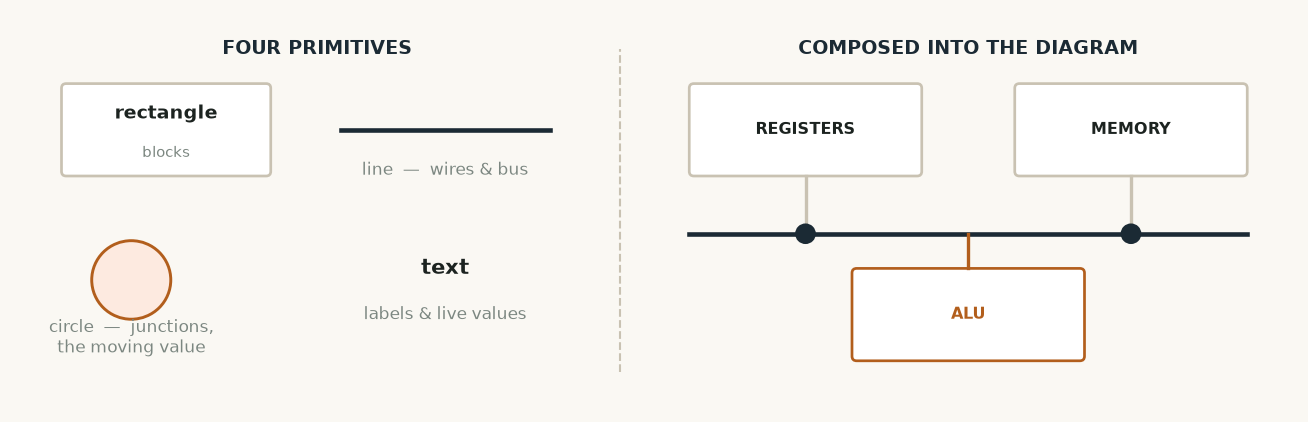

In [ ]:
fig, ax = canvas(h=3.4, ylim=(0, 34))
label(ax, 26, 31, "FOUR PRIMITIVES", color=NAVY, fs=9.3, weight="bold")
box(ax, 4, 20, 18, 8, "rectangle", "blocks", fc="white")
ax.plot([28, 46], [24, 24], color=NAVY, lw=2.2); label(ax, 37, 20.5, "line  \u2014  wires & bus", fs=8)
ax.add_patch(Circle((10, 11), 3.4, facecolor="#FDEAE0", edgecolor=COPPER, lw=1.4))
label(ax, 10, 6, "circle  \u2014  junctions,\nthe moving value", fs=8)
label(ax, 37, 12, "text", color=INK, fs=10, weight="bold")
label(ax, 37, 8, "labels & live values", fs=8)
ax.plot([52, 52], [3, 31], color=LINE, lw=1, ls="--")
label(ax, 82, 31, "COMPOSED INTO THE DIAGRAM", color=NAVY, fs=9.3, weight="bold")
box(ax, 58, 20, 20, 8, "REGISTERS", "", fc="white", fs=7.5)
box(ax, 86, 20, 20, 8, "MEMORY", "", fc="white", fs=7.5)
ax.plot([58, 106], [15, 15], color=NAVY, lw=2.2)
for x in (68, 96):
    ax.plot([x, x], [15, 20], color=LINE, lw=1.6)
    ax.add_patch(Circle((x, 15), 0.8, color=NAVY, zorder=3))
box(ax, 72, 4, 20, 8, "ALU", "", fc="white", ec=COPPER, tc=COPPER, fs=7.5)
ax.plot([82, 82], [12, 15], color=COPPER, lw=1.6)
plt.show()

| Primitive | What it draws |
|---|---|
| Rectangle | the register file, control unit, memory and ALU blocks |
| Line | the shared data bus and every wire dropping onto it |
| Circle | bus junctions, and the value travelling along the bus |
| Text | labels, register contents, ALU operands and results |

A wire is drawn in one colour when idle and another when it is carrying a value in the
current cycle — which is what makes the datapath appear to light up as you step.

```cpp
Pixel busPix = sig.busActive ? PX_ACTIVE : PX_WIRE;
c.drawLineBresenham(2, busY, W - 3, busY, busPix);
```

---
## CO2 · Solve real-time problems using geometric transformations

Two transformations do real work in the interface.

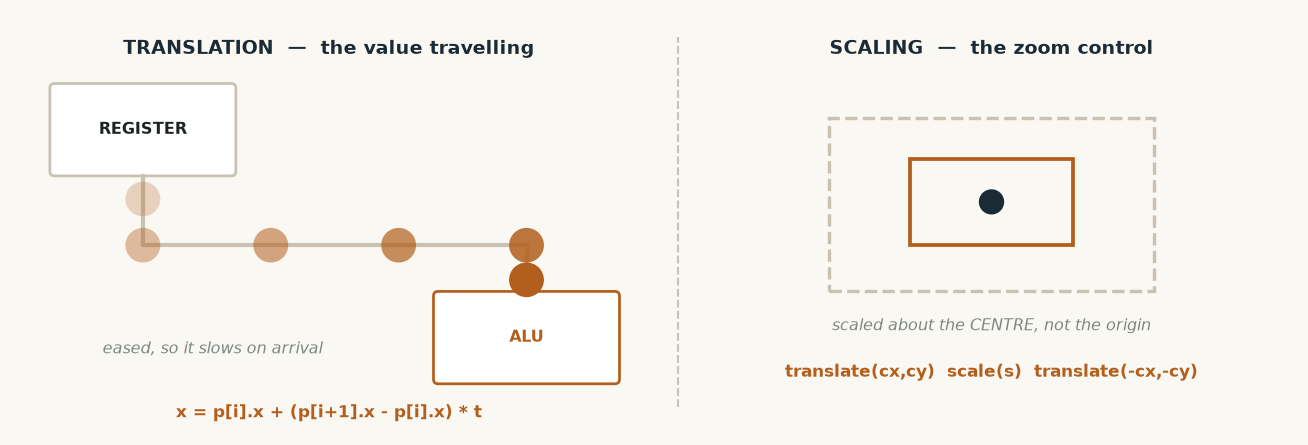

In [ ]:
fig, ax = canvas(h=3.6, ylim=(0, 36))
label(ax, 27, 33, "TRANSLATION  \u2014  the value travelling", color=NAVY, fs=9.3, weight="bold")
box(ax, 3, 22, 16, 8, "REGISTER", "", fc="white", fs=7.5)
box(ax, 36, 4, 16, 8, "ALU", "", fc="white", ec=COPPER, tc=COPPER, fs=7.5)
ax.plot([11, 11, 44, 44], [22, 16, 16, 12], color=LINE, lw=2)
for i, (px, py) in enumerate([(11, 20), (11, 16), (22, 16), (33, 16), (44, 16), (44, 13)]):
    a = 0.25 + i*0.15
    ax.add_patch(Circle((px, py), 1.5, facecolor=COPPER, alpha=min(a, 1), edgecolor="none", zorder=5))
label(ax, 17, 7, "eased, so it slows on arrival", fs=7.8, style="italic")
label(ax, 27, 1.5, "x = p[i].x + (p[i+1].x - p[i].x) * t", color=COPPER, fs=8.4, weight="bold")
ax.plot([57, 57], [2, 34], color=LINE, lw=1, ls="--")
label(ax, 84, 33, "SCALING  \u2014  the zoom control", color=NAVY, fs=9.3, weight="bold")
ax.add_patch(Rectangle((70, 12), 28, 15, fill=False, edgecolor=LINE, lw=1.6, ls="--"))
ax.add_patch(Rectangle((77, 16), 14, 7.5, fill=False, edgecolor=COPPER, lw=1.8))
ax.add_patch(Circle((84, 19.75), 1.0, color=NAVY, zorder=4))
label(ax, 84, 9, "scaled about the CENTRE, not the origin", fs=7.8, style="italic")
label(ax, 84, 5, "translate(cx,cy)  scale(s)  translate(-cx,-cy)", color=COPPER, fs=8.2, weight="bold")
plt.show()

**Translation** moves the value from source to destination. The route is a list of
waypoints — out of the register, down to the bus, across, and up into the ALU — and the
position is interpolated along that path on every frame, eased so it decelerates as it
arrives. A trail is drawn behind it, so the whole **route** is visible rather than only
the endpoints.

**Scaling** drives the zoom. The factor is applied about the **centre** of the diagram
rather than the origin, so zooming expands from the middle instead of dragging the
picture towards a corner.

```js
scene.setAttribute("transform",
    "translate(380,205) scale(" + s + ") translate(-380,-205)");
```

---
## Held back for later parts

This notebook covers **CO1 and CO2 only** — the deliberate scope of the first working
prototype. The remaining outcomes are planned work, listed here so the omission reads
as planning rather than a gap.

| Outcome | Topic | Where it will be used |
|---|---|---|
| CO3 | 2D and 3D objects using various algorithms | Our own Bresenham line and circle, and scan-line polygon fill |
| CO5 | Clipping algorithms | Cohen–Sutherland, so wires cut cleanly at the edge when panning |
| CO4, CO6 | Projection, viewing, light and texture | A 3D view of the processor, which needs the OpenGL path |

---
*Datapath Bench — an integrated SY B.Tech project.*
*Vivek Dhamale · Pranjal Bhandari · Sanika Patil · Mrudula Bongulwar.*
*Guide: Mrs. Jaya S. Mane, Assistant Professor, Software Engineering Department.*